# Лабораторная работа №2. Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных

**Датасет:** Titanic (Kaggle, соревнование "Titanic - Machine Learning from Disaster")

**Курс:** Технологии машинного обучения

**Цель работы:** изучение способов предварительной обработки данных для дальнейшего формирования моделей.

**Задание:**
1. Выбрать набор данных, содержащий категориальные признаки и пропуски в данных.
2. Для выбранного датасета решить следующие задачи:
   - обработку пропусков в данных;
   - кодирование категориальных признаков;
   - масштабирование данных.


## 1. Текстовое описание набора данных

Используется датасет **Titanic** с платформы Kaggle (соревнование
[Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data)).
Файл `train.csv` сохранён локально в `data/titanic.csv`.

Датасет содержит данные о пассажирах парохода «Титаник»: демографические характеристики,
класс билета, стоимость проезда, каюту, порт посадки и признак выживания.

Датасет выбран для данной лабораторной работы, поскольку одновременно содержит:
- **пропуски в данных** — в столбцах `Age`, `Cabin`, `Embarked`;
- **категориальные признаки** — `Sex`, `Embarked`, `Pclass`, `Cabin` (после извлечения палубы);
- количественные признаки разного масштаба — `Age`, `Fare`, `SibSp`, `Parch`,
  что делает его удобным сразу для всех трёх задач лабораторной работы (пропуски, кодирование, масштабирование)
  без необходимости брать несколько разных наборов данных.

**Описание столбцов:**
- `PassengerId` — идентификатор пассажира;
- `Survived` — целевая переменная (0 — погиб, 1 — выжил);
- `Pclass` — класс билета (1, 2, 3) — категориальный порядковый признак;
- `Name`, `Ticket` — текстовые идентификаторы (не используются как признаки);
- `Sex` — пол — категориальный признак;
- `Age` — возраст — количественный признак, есть пропуски;
- `SibSp` — количество супругов/братьев/сестёр на борту;
- `Parch` — количество родителей/детей на борту;
- `Fare` — стоимость билета;
- `Cabin` — номер каюты — категориальный признак, много пропусков;
- `Embarked` — порт посадки (C/Q/S) — категориальный признак, есть пропуски.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("data/titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Основные характеристики датасета

In [2]:
print(f"Размер датасета: {df.shape[0]} наблюдений, {df.shape[1]} столбцов")
print()
df.info()


Размер датасета: 891 наблюдений, 12 столбцов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_report


,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


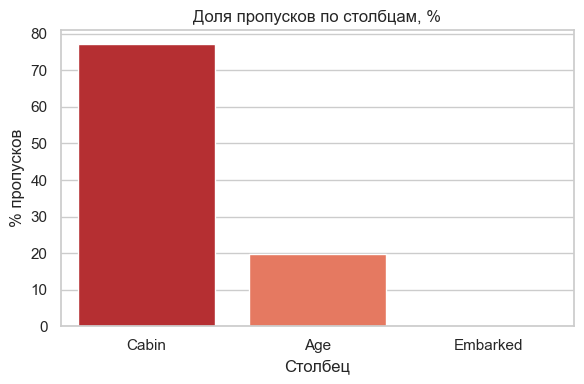

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=missing_report.index, y=missing_report["missing_pct"], hue=missing_report.index,
            palette="Reds_r", legend=False, ax=ax)
ax.set_title("Доля пропусков по столбцам, %")
ax.set_ylabel("% пропусков")
ax.set_xlabel("Столбец")
plt.tight_layout()
plt.show()


In [5]:
categorical_cols = ["Sex", "Embarked", "Pclass", "Cabin"]
numeric_cols = ["Age", "SibSp", "Parch", "Fare"]

print("Категориальные признаки:", categorical_cols)
print("Количественные признаки:", numeric_cols)
print()
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"Уникальные значения '{col}':", df[col].unique())


Категориальные признаки: ['Sex', 'Embarked', 'Pclass', 'Cabin']
Количественные признаки: ['Age', 'SibSp', 'Parch', 'Fare']

Уникальные значения 'Sex': ['male' 'female']
Уникальные значения 'Embarked': ['S' 'C' 'Q' nan]
Уникальные значения 'Pclass': [3 1 2]


**Выводы по характеристикам:**
- В датасете 891 наблюдение, 12 столбцов.
- Пропуски есть в трёх столбцах: `Age` (~19.9%), `Cabin` (~77.1%), `Embarked` (~0.2%).
- Категориальные признаки: `Sex` (бинарный), `Embarked` (3 категории + пропуски), `Pclass` (3 порядковые категории), `Cabin` (много уникальных значений, большая доля пропусков).


## 3. Обработка пропусков в данных

Применим разные стратегии обработки пропусков в зависимости от столбца и доли пропущенных значений:

- **`Embarked`** (пропусков мало, 0.22%) — заполняем модой (самым частым портом посадки).
- **`Age`** (пропусков ~20%) — заполняем медианным значением, рассчитанным отдельно по группам `Pclass` и `Sex`, что точнее простого заполнения общей медианой.
- **`Cabin`** (пропусков ~77%) — слишком много пропусков, чтобы восстанавливать точное значение. Вместо удаления признака извлекаем из него новый признак `Deck` (первая буква каюты), а пропуски кодируем отдельной категорией `"Unknown"`.


In [6]:
df_clean = df.copy()

# Embarked: заполнение модой
embarked_mode = df_clean["Embarked"].mode()[0]
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)
print(f"Embarked заполнен модой: '{embarked_mode}'")


Embarked заполнен модой: 'S'


In [7]:
# Age: заполнение медианой по группам Pclass + Sex
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(lambda s: s.fillna(s.median()))
# на случай, если в какой-то группе не нашлось значений — подстраховка общей медианой
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
print("Пропусков в Age после обработки:", df_clean["Age"].isna().sum())


Пропусков в Age после обработки: 0


In [8]:
# Cabin: извлекаем палубу (первая буква), пропуски -> отдельная категория "Unknown"
df_clean["Deck"] = df_clean["Cabin"].str[0]
df_clean["Deck"] = df_clean["Deck"].fillna("Unknown")
print("Распределение по палубам:")
print(df_clean["Deck"].value_counts())


Распределение по палубам:
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


In [9]:
print("Пропуски до обработки:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Пропуски после обработки (Age, Embarked, Deck):")
print(df_clean[["Age", "Embarked", "Deck"]].isna().sum())


Пропуски до обработки:
Age         177
Cabin       687
Embarked      2
dtype: int64

Пропуски после обработки (Age, Embarked, Deck):
Age         0
Embarked    0
Deck        0
dtype: int64


## 4. Кодирование категориальных признаков

Используем разные способы кодирования в зависимости от природы признака:

- **`Sex`** — бинарный признак, применяем **Label Encoding** (male/female → 0/1).
- **`Embarked`**, **`Deck`** — номинальные признаки без порядка, применяем **One-Hot Encoding**.
- **`Pclass`** — порядковый категориальный признак (1 < 2 < 3 по классу обслуживания), оставляем как есть в числовом виде — порядок уже заложен в исходных значениях.


In [10]:
le = LabelEncoder()
df_clean["Sex_encoded"] = le.fit_transform(df_clean["Sex"])
print("Соответствие категорий Sex:", dict(zip(le.classes_, le.transform(le.classes_))))
df_clean[["Sex", "Sex_encoded"]].head()


Соответствие категорий Sex: {'female': np.int64(0), 'male': np.int64(1)}


,Sex,Sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [11]:
ohe_cols = ["Embarked", "Deck"]
df_encoded = pd.get_dummies(df_clean, columns=ohe_cols, prefix=ohe_cols)

new_cols = [c for c in df_encoded.columns if c.startswith("Embarked_") or c.startswith("Deck_")]
print(f"Добавлено {len(new_cols)} one-hot столбцов:")
print(new_cols)
df_encoded[new_cols].head()


Добавлено 12 one-hot столбцов:
['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


,Embarked_C,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,False,False,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,True
3,False,False,True,False,False,True,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False,True


## 5. Масштабирование данных

Количественные признаки (`Age`, `Fare`, `SibSp`, `Parch`) имеют очень разные диапазоны значений
(например, `Fare` — от 0 до 512, `Age` — от 0 до 80), поэтому для моделей, чувствительных к
масштабу признаков (линейные модели, метод ближайших соседей, нейронные сети), их необходимо
привести к единому масштабу.

Сравним два подхода:
- **StandardScaler** — приводит признак к нулевому среднему и единичной дисперсии (Z-score);
- **MinMaxScaler** — приводит признак к диапазону [0, 1].


In [12]:
scale_cols = ["Age", "Fare", "SibSp", "Parch"]

print("Статистика ДО масштабирования:")
df_encoded[scale_cols].describe().T[["mean", "std", "min", "max"]]


Статистика ДО масштабирования:


,mean,std,min,max
Age,29.112424,13.304424,0.42,80.0000
Fare,32.204208,49.693429,0.00,512.3292
SibSp,0.523008,1.102743,0.00,8.0000
Parch,0.381594,0.806057,0.00,6.0000


In [13]:
standard_scaler = StandardScaler()
df_encoded[[f"{c}_standard" for c in scale_cols]] = standard_scaler.fit_transform(df_encoded[scale_cols])

minmax_scaler = MinMaxScaler()
df_encoded[[f"{c}_minmax" for c in scale_cols]] = minmax_scaler.fit_transform(df_encoded[scale_cols])

df_encoded[scale_cols + [f"{c}_standard" for c in scale_cols] + [f"{c}_minmax" for c in scale_cols]].head()


,Age,Fare,SibSp,Parch,Age_standard,Fare_standard,SibSp_standard,Parch_standard,Age_minmax,Fare_minmax,SibSp_minmax,Parch_minmax
0,22.0,7.2500,1,0,-0.534891,-0.502445,0.432793,-0.473674,0.271174,0.014151,0.125,0.0
1,38.0,71.2833,1,0,0.668392,0.786845,0.432793,-0.473674,0.472229,0.139136,0.125,0.0
2,26.0,7.9250,0,0,-0.234070,-0.488854,-0.474545,-0.473674,0.321438,0.015469,0.000,0.0
3,35.0,53.1000,1,0,0.442776,0.420730,0.432793,-0.473674,0.434531,0.103644,0.125,0.0
4,35.0,8.0500,0,0,0.442776,-0.486337,-0.474545,-0.473674,0.434531,0.015713,0.000,0.0


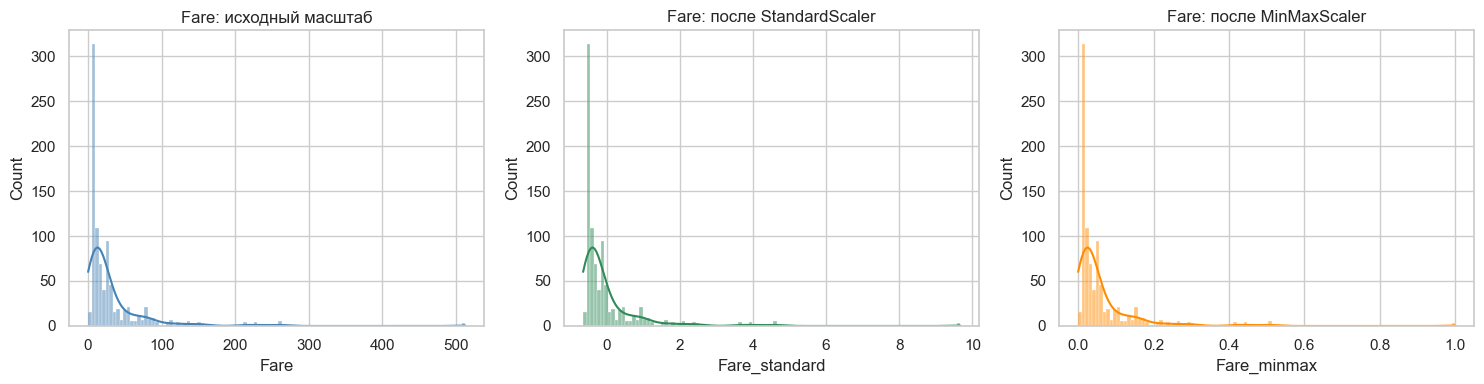

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_encoded["Fare"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Fare: исходный масштаб")

sns.histplot(df_encoded["Fare_standard"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Fare: после StandardScaler")

sns.histplot(df_encoded["Fare_minmax"], kde=True, ax=axes[2], color="darkorange")
axes[2].set_title("Fare: после MinMaxScaler")

plt.tight_layout()
plt.show()


In [15]:
print("Статистика ПОСЛЕ StandardScaler (mean≈0, std≈1):")
print(df_encoded[[f"{c}_standard" for c in scale_cols]].describe().T[["mean", "std", "min", "max"]].round(3))
print()
print("Статистика ПОСЛЕ MinMaxScaler (диапазон [0, 1]):")
print(df_encoded[[f"{c}_minmax" for c in scale_cols]].describe().T[["mean", "std", "min", "max"]].round(3))


Статистика ПОСЛЕ StandardScaler (mean≈0, std≈1):
                mean    std    min    max
Age_standard     0.0  1.001 -2.158  3.827
Fare_standard    0.0  1.001 -0.648  9.667
SibSp_standard   0.0  1.001 -0.475  6.784
Parch_standard   0.0  1.001 -0.474  6.974

Статистика ПОСЛЕ MinMaxScaler (диапазон [0, 1]):
               mean    std  min  max
Age_minmax    0.361  0.167  0.0  1.0
Fare_minmax   0.063  0.097  0.0  1.0
SibSp_minmax  0.065  0.138  0.0  1.0
Parch_minmax  0.064  0.134  0.0  1.0


## 6. Итоговый датасет, готовый к обучению модели

Соберём финальный набор признаков: числовые масштабированные признаки, `Sex_encoded`,
one-hot столбцы `Embarked_*` и `Deck_*`, а также `Pclass` в исходном виде.


In [16]:
feature_cols = (
    [f"{c}_standard" for c in scale_cols]
    + ["Sex_encoded", "Pclass"]
    + [c for c in df_encoded.columns if c.startswith("Embarked_") or c.startswith("Deck_")]
)

final_df = df_encoded[feature_cols + ["Survived"]]
print(f"Итоговая размерность датасета для обучения модели: {final_df.shape}")
final_df.head()


Итоговая размерность датасета для обучения модели: (891, 19)


,Age_standard,Fare_standard,SibSp_standard,Parch_standard,Sex_encoded,Pclass,Embarked_C,Embarked_Q,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown,Survived
0,-0.534891,-0.502445,0.432793,-0.473674,1,3,False,False,True,False,False,False,False,False,False,False,False,True,0
1,0.668392,0.786845,0.432793,-0.473674,0,1,True,False,False,False,False,True,False,False,False,False,False,False,1
2,-0.234070,-0.488854,-0.474545,-0.473674,0,3,False,False,True,False,False,False,False,False,False,False,False,True,1
3,0.442776,0.420730,0.432793,-0.473674,0,1,False,False,True,False,False,True,False,False,False,False,False,False,1
4,0.442776,-0.486337,-0.474545,-0.473674,1,3,False,False,True,False,False,False,False,False,False,False,False,True,0


## Итоговые выводы

1. Датасет Titanic (Kaggle) содержит пропуски в трёх столбцах (`Age`, `Cabin`, `Embarked`) и несколько категориальных признаков разной природы (бинарный, номинальные, порядковый).
2. Для обработки пропусков применены разные стратегии в зависимости от доли пропущенных значений: заполнение модой (`Embarked`), заполнение медианой по группам (`Age`), выделение отдельной категории «Unknown» вместо удаления признака (`Cabin` → `Deck`).
3. Для кодирования категориальных признаков использованы Label Encoding (бинарный признак `Sex`) и One-Hot Encoding (номинальные признаки `Embarked`, `Deck`); порядковый признак `Pclass` оставлен в исходном числовом виде.
4. Для масштабирования количественных признаков (`Age`, `Fare`, `SibSp`, `Parch`) применены StandardScaler и MinMaxScaler; сравнение показало, что оба метода убирают различия в исходном масштабе признаков, но по-разному влияют на диапазон значений (Z-score против [0, 1]).
5. В результате получен полностью числовой датасет без пропусков, готовый для использования в моделях машинного обучения.
